1/ Import data from github shared repository

In [2]:
#Import packages

import pandas as pd
import statsmodels.api as sm
import numpy as np
from tqdm import tqdm
from scipy import stats
import matplotlib.pyplot as plt

In [3]:
#Load the dataset from GitHub

dtypes = {col: 'float32' for col in ['list_of_numerical_columns']}

#USe CPI dates from 1958 to Febraury 1972
CPI_announcement_dates = "https://raw.githubusercontent.com/carolinebazeli/Memoire_HEC/refs/heads/master/CPI_announcement_date.csv"
CPI_announcement_dates = pd.read_csv(CPI_announcement_dates, dtype=dtypes)

#Use PPI dates from 1972 to 2024
PPI_announcement_dates = "https://raw.githubusercontent.com/carolinebazeli/Memoire_HEC/refs/heads/master/PPI_announcement_date.csv"
PPI_announcement_dates = pd.read_csv(PPI_announcement_dates, dtype=dtypes)

#FOMC scheduled interest rate announcement dates from 1990 to 2024
FOMC_announcement_dates = "https://raw.githubusercontent.com/carolinebazeli/Memoire_HEC/refs/heads/master/FOMC_announcement_date.csv"
FOMC_announcement_dates = pd.read_csv(FOMC_announcement_dates, dtype=dtypes)

#Stock market proxy - CRPS NYSE value-weighted index of all listed shares
NYSE_daily_stock_returns = r"C:/Users/bazel/Documents/Master in Finance/Mémoire/Data/Stocks/NYSE_daily_stock_returns.csv"
NYSE_daily_stock_returns = pd.read_csv(NYSE_daily_stock_returns, dtype=dtypes)

#Stock market proxy - CRPS Amex value-weighted index of all listed shares
Amex_daily_stock_returns = r"C:/Users/bazel/Documents/Master in Finance/Mémoire/Data/Stocks/Amex_daily_stock_returns.csv"
Amex_daily_stock_returns = pd.read_csv(Amex_daily_stock_returns, dtype=dtypes)

#Stock market proxy - CRPS Nasdaq value-weighted index of all listed shares
Nasdaq_daily_stock_returns = r"C:/Users/bazel/Documents/Master in Finance/Mémoire/Data/Stocks/Nasdaq_daily_stock_returns.csv"
Nasdaq_daily_stock_returns = pd.read_csv(Nasdaq_daily_stock_returns, dtype=dtypes)

#Fama_French_25_portfolio_daily (Equal_Weighted=EV, Value_Weighted=VW)
Fama_French_25_portfolio_daily ="https://raw.githubusercontent.com/carolinebazeli/Memoire_HEC/refs/heads/master/25_Portfolios_Size_BM_Daily.csv"
Fama_French_25_portfolio_daily_EV = pd.read_csv(Fama_French_25_portfolio_daily, skiprows=18, nrows=25920-19, dtype=dtypes)
Fama_French_25_portfolio_daily_VW = pd.read_csv(Fama_French_25_portfolio_daily, skiprows=25923, nrows=51825-25924, dtype=dtypes)

#Ten_industry_portfolio_daily (Equal_Weighted=EV, Value_Weighted=VW)
Ten_industry_portfolio_daily = "https://raw.githubusercontent.com/carolinebazeli/Memoire_HEC/refs/heads/master/10_Industry_Portfolios_Daily.csv"
Ten_industry_portfolio_daily_EV = pd.read_csv(Ten_industry_portfolio_daily, skiprows=9, nrows=25911 - 10, dtype=dtypes)
Ten_industry_portfolio_daily_VW = pd.read_csv(Ten_industry_portfolio_daily, skiprows=25914, nrows=51816 - 25915, dtype=dtypes)

#Fama_French_3_factor_daily
Fama_French_3_factor_daily = "https://raw.githubusercontent.com/carolinebazeli/Memoire_HEC/refs/heads/master/F-F_3_Factors_Daily.CSV"
Fama_French_3_factor_daily = pd.read_csv(Fama_French_3_factor_daily, skiprows=4, nrows=25906 - 5, dtype=dtypes)

C:\Users\bazel\AppData\Local\Temp\ipykernel_7124\701553134.py:19: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  NYSE_daily_stock_returns = pd.read_csv(NYSE_daily_stock_returns, dtype=dtypes)


In [4]:
#Convert NYSE, Amex and Nasdaq stock returns to a Dataframe, where each column is a stock and each row is a date, and the value is the daily return of that stock

NYSE_daily_stock_returns = NYSE_daily_stock_returns.drop(columns=['PERMNO','EXCHCD'])
NYSE_daily_stock_returns['RET'] = pd.to_numeric(NYSE_daily_stock_returns['RET'], errors='coerce')
NYSE_daily_stock_returns = NYSE_daily_stock_returns.groupby(['date', 'TICKER'])['RET'].mean().reset_index()
NYSE_daily_stock_returns = NYSE_daily_stock_returns.pivot(index='date', columns='TICKER', values='RET').reset_index()

Amex_daily_stock_returns = Amex_daily_stock_returns.drop(columns=['PERMNO','EXCHCD'])
Amex_daily_stock_returns['RET'] = pd.to_numeric(Amex_daily_stock_returns['RET'], errors='coerce')
Amex_daily_stock_returns = Amex_daily_stock_returns.groupby(['date', 'TICKER'])['RET'].mean().reset_index()
Amex_daily_stock_returns = Amex_daily_stock_returns.pivot(index='date', columns='TICKER', values='RET').reset_index()

Nasdaq_daily_stock_returns = Nasdaq_daily_stock_returns.drop(columns=['PERMNO','EXCHCD'])
Nasdaq_daily_stock_returns['RET'] = pd.to_numeric(Nasdaq_daily_stock_returns['RET'], errors='coerce')
Nasdaq_daily_stock_returns = Nasdaq_daily_stock_returns.groupby(['date', 'TICKER'])['RET'].mean().reset_index()
Nasdaq_daily_stock_returns = Nasdaq_daily_stock_returns.pivot(index='date', columns='TICKER', values='RET').reset_index()


In [5]:
#Convert date columns to datetime format
CPI_announcement_dates = CPI_announcement_dates.rename(columns = {'Release Dates': 'A_date'})
CPI_announcement_dates['A_date'] = pd.to_datetime(CPI_announcement_dates['A_date']).dt.date

PPI_announcement_dates = PPI_announcement_dates.rename(columns = {'Release Dates': 'A_date'})
PPI_announcement_dates['A_date'] = pd.to_datetime(PPI_announcement_dates['A_date']).dt.date

FOMC_announcement_dates = FOMC_announcement_dates.rename(columns = {'FOMC Meeting Date': 'A_date'}).reset_index(drop=True)
FOMC_announcement_dates['A_date'] = pd.to_datetime(FOMC_announcement_dates['A_date']).dt.date

NYSE_daily_stock_returns = NYSE_daily_stock_returns.rename(columns = {'date': 'Date'})
NYSE_daily_stock_returns['Date'] = pd.to_datetime(NYSE_daily_stock_returns['Date'], errors='coerce').dt.date

Amex_daily_stock_returns = Amex_daily_stock_returns.rename(columns = {'date': 'Date'})
Amex_daily_stock_returns['Date'] = pd.to_datetime(Amex_daily_stock_returns['Date'], errors='coerce').dt.date

Nasdaq_daily_stock_returns = Nasdaq_daily_stock_returns.rename(columns = {'date': 'Date'})
Nasdaq_daily_stock_returns['Date'] = pd.to_datetime(Nasdaq_daily_stock_returns['Date'], errors='coerce').dt.date

Fama_French_25_portfolio_daily_EV = Fama_French_25_portfolio_daily_EV.rename(columns = {'Unnamed: 0': 'Date'})
Fama_French_25_portfolio_daily_EV['Date'] = pd.to_datetime(Fama_French_25_portfolio_daily_EV['Date'].astype(str), format='%Y%m%d').dt.date

Fama_French_25_portfolio_daily_VW = Fama_French_25_portfolio_daily_VW.rename(columns = {'Unnamed: 0': 'Date'})
Fama_French_25_portfolio_daily_VW['Date'] = pd.to_datetime(Fama_French_25_portfolio_daily_VW['Date'].astype(str), format='%Y%m%d').dt.date

Ten_industry_portfolio_daily_EV = Ten_industry_portfolio_daily_EV.rename(columns = {'Unnamed: 0': 'Date'})
Ten_industry_portfolio_daily_EV['Date'] = pd.to_datetime(Ten_industry_portfolio_daily_EV['Date'].astype(str), format='%Y%m%d').dt.date

Ten_industry_portfolio_daily_VW = Ten_industry_portfolio_daily_VW.rename(columns = {'Unnamed: 0': 'Date'})
Ten_industry_portfolio_daily_VW['Date'] = pd.to_datetime(Ten_industry_portfolio_daily_VW['Date'].astype(str), format='%Y%m%d').dt.date

Fama_French_3_factor_daily = Fama_French_3_factor_daily.rename(columns = {'Unnamed: 0': 'Date'})
Fama_French_3_factor_daily['Date'] = pd.to_datetime(Fama_French_3_factor_daily['Date'].astype(str), format='%Y%m%d').dt.date

C:\Users\bazel\AppData\Local\Temp\ipykernel_7124\2790959862.py:9: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  FOMC_announcement_dates['A_date'] = pd.to_datetime(FOMC_announcement_dates['A_date']).dt.date


In [6]:
#Merge the three dataset NYSE, Amex and Nasdaq into a single one:

stock_market_daily_returns = NYSE_daily_stock_returns.merge(
    Amex_daily_stock_returns, on='Date', how='outer'
).merge(
    Nasdaq_daily_stock_returns, on='Date', how='outer'
)

cols = ['Date'] + sorted([col for col in stock_market_daily_returns.columns if col != 'Date'])
stock_market_daily_returns = stock_market_daily_returns[cols]

2/ Split data between announcement days and non-announcement days for each portfolio

In [7]:
#Select CPI_announcement_dates up until February 1972
CPI_announcement_dates = CPI_announcement_dates.loc[CPI_announcement_dates['A_date'] <= pd.to_datetime('1972-02-01').date()]
CPI_announcement_dates = CPI_announcement_dates.reset_index(drop=True)

#Select PPI_announcement_dates from February 1972
PPI_announcement_dates = PPI_announcement_dates.loc[PPI_announcement_dates['A_date'] > pd.to_datetime('1972-02-01').date()]
PPI_announcement_dates = PPI_announcement_dates.reset_index(drop=True)

In [8]:
all_A_dates = pd.concat([
    CPI_announcement_dates['A_date'],
    FOMC_announcement_dates['A_date'],
    PPI_announcement_dates['A_date']
])

stock_market_daily_returns_A_Day = stock_market_daily_returns[stock_market_daily_returns['Date'].isin(all_A_dates)].reset_index(drop=True)
stock_market_daily_returns_N_Day = stock_market_daily_returns[~stock_market_daily_returns['Date'].isin(all_A_dates)].reset_index(drop=True)

Fama_French_25_portfolio_daily_EV_A_Day = Fama_French_25_portfolio_daily_EV[Fama_French_25_portfolio_daily_EV['Date'].isin(all_A_dates)].reset_index(drop=True)
Fama_French_25_portfolio_daily_VW_A_Day = Fama_French_25_portfolio_daily_VW[Fama_French_25_portfolio_daily_VW['Date'].isin(all_A_dates)].reset_index(drop=True)
Ten_industry_portfolio_daily_VW_A_Day = Ten_industry_portfolio_daily_VW[Ten_industry_portfolio_daily_VW['Date'].isin(all_A_dates)].reset_index(drop=True)
Ten_industry_portfolio_daily_EV_A_Day = Ten_industry_portfolio_daily_EV[Ten_industry_portfolio_daily_EV['Date'].isin(all_A_dates)].reset_index(drop=True)

Fama_French_25_portfolio_daily_EV_N_Day = Fama_French_25_portfolio_daily_EV[~Fama_French_25_portfolio_daily_EV['Date'].isin(all_A_dates)].reset_index(drop=True)
Fama_French_25_portfolio_daily_VW_N_Day = Fama_French_25_portfolio_daily_VW[~Fama_French_25_portfolio_daily_VW['Date'].isin(all_A_dates)].reset_index(drop=True)
Ten_industry_portfolio_daily_VW_N_Day = Ten_industry_portfolio_daily_VW[~Ten_industry_portfolio_daily_VW['Date'].isin(all_A_dates)].reset_index(drop=True)
Ten_industry_portfolio_daily_EV_N_Day = Ten_industry_portfolio_daily_EV[~Ten_industry_portfolio_daily_EV['Date'].isin(all_A_dates)].reset_index(drop=True)


In [9]:
#add the daily market Equity Risk premium and risk-free rate to all the portfolios

Fama_French_3_factor_daily = Fama_French_3_factor_daily.rename(columns={'Mkt-RF': 'Equity Risk Premium', 'RF': 'Risk-Free Rate'})

df_names = [
    'stock_market_daily_returns',
    'stock_market_daily_returns_A_Day',
    'stock_market_daily_returns_N_Day',
    'Fama_French_25_portfolio_daily_EV',
    'Fama_French_25_portfolio_daily_VW',
    'Ten_industry_portfolio_daily_VW',
    'Ten_industry_portfolio_daily_EV',
    'Fama_French_25_portfolio_daily_EV_A_Day',
    'Fama_French_25_portfolio_daily_VW_A_Day',
    'Ten_industry_portfolio_daily_VW_A_Day',
    'Ten_industry_portfolio_daily_EV_A_Day',
    'Fama_French_25_portfolio_daily_EV_N_Day',
    'Fama_French_25_portfolio_daily_VW_N_Day',
    'Ten_industry_portfolio_daily_VW_N_Day',
    'Ten_industry_portfolio_daily_EV_N_Day'
]

#Convert to decimal format (from percent) to match stock's returns format 
Fama_French_3_factor_daily[['Equity Risk Premium', 'Risk-Free Rate']] /= 100

ff3_cols = ['Date', 'Equity Risk Premium', 'Risk-Free Rate']

for name in df_names:
    globals()[name] = globals()[name].merge(Fama_French_3_factor_daily[ff3_cols], on='Date', how='left')

In [10]:
#Select stock market returns only from 2010 to 2024 - to test
stock_market_daily_returns['Date'] = pd.to_datetime(stock_market_daily_returns['Date'])
stock_market_daily_returns_2010 = stock_market_daily_returns.loc[stock_market_daily_returns['Date'] >= pd.to_datetime('2010-01-01')].reset_index(drop=True)

stock_market_daily_returns_A_Day['Date'] = pd.to_datetime(stock_market_daily_returns_A_Day['Date'])
stock_market_daily_returns_2010_A_Day = stock_market_daily_returns_A_Day.loc[stock_market_daily_returns_A_Day['Date'] >= pd.to_datetime('2010-01-01')].reset_index(drop=True)

stock_market_daily_returns_N_Day['Date'] = pd.to_datetime(stock_market_daily_returns_N_Day['Date'])
stock_market_daily_returns_2010_N_Day = stock_market_daily_returns_N_Day.loc[stock_market_daily_returns_N_Day['Date'] >= pd.to_datetime('2010-01-01')].reset_index(drop=True)

In [11]:
#Select stock market returns only from 1990 to 2024 - to test
stock_market_daily_returns['Date'] = pd.to_datetime(stock_market_daily_returns['Date'])
stock_market_daily_returns_1990 = stock_market_daily_returns.loc[stock_market_daily_returns['Date'] >= pd.to_datetime('1990-01-01')].reset_index(drop=True)

stock_market_daily_returns_A_Day['Date'] = pd.to_datetime(stock_market_daily_returns_A_Day['Date'])
stock_market_daily_returns_1990_A_Day = stock_market_daily_returns_A_Day.loc[stock_market_daily_returns_A_Day['Date'] >= pd.to_datetime('1990-01-01')].reset_index(drop=True)

stock_market_daily_returns_N_Day['Date'] = pd.to_datetime(stock_market_daily_returns_N_Day['Date'])
stock_market_daily_returns_1990_N_Day = stock_market_daily_returns_N_Day.loc[stock_market_daily_returns_N_Day['Date'] >= pd.to_datetime('1990-01-01')].reset_index(drop=True)


In [12]:
#Select stock market returns only from 1964 to 2011 - to test exactly like in the paper
stock_market_daily_returns['Date'] = pd.to_datetime(stock_market_daily_returns['Date'])
stock_market_daily_returns_1964_2011 = stock_market_daily_returns.loc[(stock_market_daily_returns['Date'] >= pd.to_datetime('1964-01-01')) & (stock_market_daily_returns['Date'] <= pd.to_datetime('2011-01-01')) ].reset_index(drop=True)

1/ Methods for computing stock market betas

In [13]:
#Step 1a - Estimate unconditionnal full-sample beta through a time-series regression - run CAPM regression on all daily data for each stock

# def compute_rolling_betas_from_dataset(data, window=252):
#     """
#     Compute 1-year rolling betas using a dataset where:
#     - rows are dates,
#     - columns: [stock1, ..., stockN, 'Equity Risk Premium', 'Risk-Free Rate']

#     Returns:
#     - DataFrame with MultiIndex (date, ticker) and column ['beta']
#     """
#     required_columns = ['Equity Risk Premium', 'Risk-Free Rate']
#     stock_columns = data.columns.difference(required_columns)
    
#     betas = []
#     end_of_months = data.resample('M').last().index

#     for current_date in end_of_months:
#         try:
#             start_idx = data.index.get_loc(current_date)
#         except KeyError:
#             continue

#         if start_idx < window:
#             continue
        
#         window_data = data.iloc[start_idx - window:start_idx]

#         if len(window_data) < 200:
#             continue

#         X = sm.add_constant(window_data['Equity Risk Premium'])

#         for stock in stock_columns:
#             y = window_data[stock] - window_data['Risk-Free Rate']

#             if y.isnull().sum() > 50:
#                 continue

#             try:
#                 model = sm.OLS(y, X, missing='drop')
#                 results = model.fit()
#                 beta = results.params['Equity Risk Premium']
#                 betas.append((current_date, stock, beta))
#             except:
#                 continue

#     betas_time_varying = pd.DataFrame(betas, columns=['date', 'ticker', 'beta'])
#     return betas_time_varying.pivot(index='date', columns='ticker', values='beta').sort_index()

def compute_full_sample_betas(data):
    """
    Compute full-sample market betas for each portfolio.

    Parameters:
    - data: DataFrame where:
        - rows are dates,
        - columns: [portfolio1, ..., portfolioN, 'Equity Risk Premium', 'Risk-Free Rate'].

    Returns:
    - Series with portfolio names as index and full-sample betas as values.
    """
    required_columns = ['Equity Risk Premium', 'Risk-Free Rate']
    portfolio_columns = data.columns.difference(required_columns)

    full_sample_betas = {}

    X = sm.add_constant(data['Equity Risk Premium'])

    for portfolio in portfolio_columns:
        y = data[portfolio] - data['Risk-Free Rate']

        if y.isnull().sum() > 50:
            continue

        try:
            model = sm.OLS(y, X, missing='drop')
            results = model.fit()
            full_sample_betas[portfolio] = results.params['Equity Risk Premium']
        except:
            continue

    return pd.Series(full_sample_betas)


In [14]:
#Step 1b - Estimate One-Year rolling window Betas (Time-Varying betas) on all daily data for each stock (unconditionnal betas)

def rolling_betas(data, window=252):
    """
    Compute 1-year rolling betas using a dataset where:
    - rows are dates (index),
    - columns: [stock1, ..., stockN, 'Equity Risk Premium', 'Risk-Free Rate']

    Returns:
    - DataFrame with MultiIndex (date, ticker) and column ['beta']
    """

    if 'Date' in data.columns:
        data.set_index('Date', inplace=True)
        data.index = pd.to_datetime(data.index, errors='coerce')
        
    required_columns = ['Equity Risk Premium', 'Risk-Free Rate']
    stock_columns = data.columns.difference(required_columns)
    
    betas = []
    
    # Resample to get the end of each month
            #end_of_months = data.resample('M').last().index
            #end_of_months = pd.date_range(start=data.index.min(), end=data.index.max(), freq='BM')
            #end_of_months = [d for d in end_of_months if d in data.index]

    end_of_months = data.groupby([data.index.year, data.index.month]).apply(lambda x: x.index.max()).sort_values()
    
    for current_date in tqdm(end_of_months, desc='Rolling beta estimation'):
        
        try:
            start_idx = data.index.get_loc(current_date)
        except KeyError:
            continue

        if start_idx < window:
            continue
        
        window_data = data.iloc[start_idx - window:start_idx]

        if len(window_data) < 200:
            continue

        X = sm.add_constant(window_data['Equity Risk Premium'])

        for stock in stock_columns:
            y = window_data[stock] - window_data['Risk-Free Rate']

            if y.isnull().sum() > 50:
                continue

            try:
                model = sm.OLS(y, X, missing='drop')
                results = model.fit()
                beta = results.params['Equity Risk Premium']
                betas.append((current_date, stock, beta))
            except:
                continue
              
    betas_time_varying = pd.DataFrame(betas, columns=['date', 'ticker', 'beta'])
    return betas_time_varying.set_index(['date', 'ticker'])['beta'].unstack()


2/ Beta in Cross-Sectional Asset Pricing Regressions

In [15]:
#Step 2a - Fama-MacBeth Two-Step Regressions (by Announcement vs Non-Announcement Days)


def fama_macbeth_cross_sectional(data_subset, rolling_betas_df):
    """
    Fama–MacBeth cross-sectional regression with 'Date' as column.

    Parameters:
        data_subset: pd.DataFrame (like Fama_French_25_portfolio_daily_EV_A_Day) - the data subset for the regression, split between A_days and N_days
            Must include 'Date', 25 portfolios, 'Equity Risk Premium', and 'Risk-Free Rate'.
        rolling_betas_df: pd.DataFrame (like ama_French_25_portfolio_daily_EV_rolling_betas) - contains the rolling beta for the whole period
            Output of rolling_betas(): index = date (datetime), columns = gamma_0, gamma_1.

    Returns:
        pd.DataFrame:
            Index = dates (t+1), columns = ['gamma_0', 'gamma_1']
    """
    # Ensure datetime and sorted
    if 'Date' in data_subset.columns:
        data_subset['Date'] = pd.to_datetime(data_subset['Date'])
        data_subset = data_subset.sort_values('Date').reset_index(drop=True)
    else:
        data_subset = data_subset.reset_index()  # assumes index is Date
        data_subset.rename(columns={data_subset.columns[0]: 'Date'}, inplace=True)
        data_subset['Date'] = pd.to_datetime(data_subset['Date'])
        data_subset = data_subset.sort_values('Date').reset_index(drop=True)

    results = []

    required_cols = ['Equity Risk Premium', 'Risk-Free Rate', 'Date']
    portfolio_cols = data_subset.columns.difference(required_cols)

    for t in tqdm(range(1, len(data_subset)), desc="Fama-MacBeth regression"):
        date_t = data_subset.loc[t, 'Date']

        # Find latest beta before date_t
        beta_dates = rolling_betas_df.index[rolling_betas_df.index <= date_t]
        if beta_dates.empty:
            continue
        date_beta = beta_dates.max()
        betas_t = rolling_betas_df.loc[date_beta]

        # Excess returns at t
        excess_returns = data_subset.loc[t, portfolio_cols] - data_subset.loc[t, 'Risk-Free Rate']

        # Match assets
        common_assets = excess_returns.dropna().index.intersection(betas_t.dropna().index)
        if len(common_assets) < 5:
            continue

        y = excess_returns[common_assets].astype(float)
        X = betas_t[common_assets].astype(float)
        X = sm.add_constant(X)

        # Drop any remaining NaNs
        valid_idx = y.index.intersection(X.dropna().index)
        y = y.loc[valid_idx]
        X = X.loc[valid_idx]

        model = sm.OLS(y, X).fit()

        results.append({
            'Date': date_t,
            'gamma_0': model.params['const'],
            'gamma_1': model.params[X.columns[1]],
            'R_squared': model.rsquared
        })

    return pd.DataFrame(results).set_index('Date')


In [16]:
#Step 2a bis - Fama-MacBeth Two-Step Regressions (by Announcement vs Non-Announcement Days) - Table Output of findings

def summarize_fama_macbeth_results(gammas_A, gammas_N):
    """
    Produce summary stats like academic table for Fama-MacBeth regressions.

    Inputs:
        gammas_A: DataFrame with columns ['gamma_0', 'gamma_1'], index = dates (A-days)
        gammas_N: DataFrame with columns ['gamma_0', 'gamma_1'], index = dates (N-days)

    Output:
        summary_df: Formatted table with mean coefficients, t-stats, R-squared and differences
    """


    def mean_se_t(series):
        mean = series.mean()
        se = series.std(ddof=1) / np.sqrt(len(series))
        t_stat = mean / se
        return mean, t_stat

    # Intercept
    gamma0_A, t0_A = mean_se_t(gammas_A['gamma_0'])
    gamma0_N, t0_N = mean_se_t(gammas_N['gamma_0'])
    diff_gamma0 = gamma0_A - gamma0_N
    t_diff_0, _ = stats.ttest_ind(gammas_A['gamma_0'], gammas_N['gamma_0'], equal_var=False)

    # Slope (beta)
    gamma1_A, t1_A = mean_se_t(gammas_A['gamma_1'])
    gamma1_N, t1_N = mean_se_t(gammas_N['gamma_1'])
    diff_gamma1 = gamma1_A - gamma1_N
    t_diff_1, _ = stats.ttest_ind(gammas_A['gamma_1'], gammas_N['gamma_1'], equal_var=False)

    # Average R²
    r2_A = gammas_A['R_squared'].mean()
    r2_N = gammas_N['R_squared'].mean()
    r2_diff = r2_A - r2_N

    # Build final DataFrame
    data = {
        "Intercept": [gamma0_A, gamma0_N, diff_gamma0],
        "Intercept t-stat": [t0_A, t0_N, t_diff_0],
        "Beta": [gamma1_A, gamma1_N, diff_gamma1],
        "Beta t-stat": [t1_A, t1_N, t_diff_1],
        "Avg R²": [r2_A, r2_N, r2_diff]
    }

    index = ['a-day', 'n-day', 'a-day − n-day']
    summary_df = pd.DataFrame(data, index=index)

    return summary_df

Method 2: Compute beta-sorted portfolio

In [17]:
#Step 2b - Function to build equally-weighted beta-sorted portfolios

def build_beta_decile_portfolios(rolling_betas, stock_returns):
    """
    Create 10 equally weighted beta-sorted portfolios based on monthly rolling betas.

    Parameters:
    - rolling_betas: DataFrame (index = end-of-month dates, columns = stocks, values = betas)
    - stock_returns: DataFrame (index = daily dates, columns = same stocks, values = daily returns)

    Returns:
    - DataFrame: index = daily dates, columns = 'Decile 1', ..., 'Decile 10', values = portfolio returns
    """

    portfolios = []

    # Make sure indexes are datetime and sorted
    rolling_betas = rolling_betas.sort_index()
    stock_returns = stock_returns.sort_index()
    
    for date in rolling_betas.index:
        # Get next month’s date range
        start = date + pd.Timedelta(days=1)
        try:
            end = rolling_betas.index[rolling_betas.index.get_loc(date) + 1]
        except IndexError:
            break  # no next month

        # Get beta values for this rebalancing date
        betas = rolling_betas.loc[date].dropna()

        # Assign each stock to a decile based on beta
        deciles = pd.qcut(betas, 10, labels=[f'Decile {i+1}' for i in range(10)])

        # Get returns for the next month
        monthly_returns = stock_returns.loc[start:end]
        if monthly_returns.empty:
            continue

        # Build portfolios
        decile_returns = {}
        for decile in deciles.unique():
            stocks_in_decile = deciles[deciles == decile].index
            # Select return data for these stocks
            decile_data = monthly_returns[stocks_in_decile].copy()
            # Calculate average daily return across the decile (equally weighted)
            decile_returns[decile] = decile_data.mean(axis=1)

        ordered_deciles = [f'Decile {i+1}' for i in range(10)]
        df = pd.DataFrame(decile_returns)
        df = df.reindex(columns=ordered_deciles)
        portfolios.append(df)

    # Combine all monthly DataFrames
    all_portfolios = pd.concat(portfolios).sort_index()

    # Add Equiry Risk Premium and Risk-Free Rate from Fama-French 3-factor model
    Fama_French_3_factor_daily['Date'] = pd.to_datetime(Fama_French_3_factor_daily['Date'], errors='coerce')
    ff3_cols = ['Date', 'Equity Risk Premium', 'Risk-Free Rate']
    all_portfolios = all_portfolios.merge(Fama_French_3_factor_daily[ff3_cols], left_index=True, right_on='Date', how='left')
    
    return all_portfolios

In [18]:
#Step 2b - draw graph of the output as in the paper

import inspect

def plot_full_sample_beta_vs_excess_return(data, data_A_Day, data_N_Day):
    """
    Compute full-sample betas, split data into A-days and N-days, and plot average excess returns.

    Parameters:
    - data: DataFrame where:
        - rows are dates,
        - columns: [portfolio1, ..., portfolioN, 'Equity Risk Premium', 'Risk-Free Rate'].
    - data_A_Day: DataFrame containing A-day dates in the 'Date' column.
    - data_N_Day: DataFrame containing N-day dates in the 'Date' column.
    """
    # Retrieve the variable name of `data`
    frame = inspect.currentframe().f_back
    dataset_name = [name for name, val in frame.f_locals.items() if val is data][0]

    
    # Check if 'Date' column exists
    if 'Date' in data_A_Day.columns and 'Date' in data_N_Day.columns:
        # Ensure the 'Date' column is in datetime format for both A-day and N-day datasets
        data_A_Day['Date'] = pd.to_datetime(data_A_Day['Date'], errors='coerce')
        data_N_Day['Date'] = pd.to_datetime(data_N_Day['Date'], errors='coerce')
    else:
        # Replace the date index as a 'Date' column, then ensure it's in datetime format
        data_A_Day = data_A_Day.reset_index().rename(columns={'index': 'Date'})
        data_A_Day['Date'] = pd.to_datetime(data_A_Day['Date'], errors='coerce')
        data_N_Day = data_N_Day.reset_index().rename(columns={'index': 'Date'})
        data_N_Day['Date'] = pd.to_datetime(data_N_Day['Date'], errors='coerce')

    # Extract A-day and N-day dates
    a_day_dates = data_A_Day['Date']
    n_day_dates = data_N_Day['Date']

    # Step 1: Compute full-sample betas
    def compute_full_sample_betas(data):
        required_columns = ['Equity Risk Premium', 'Risk-Free Rate']
        portfolio_columns = data.columns.difference(required_columns)

        full_sample_betas = {}

        X = sm.add_constant(data['Equity Risk Premium'])

        for portfolio in portfolio_columns:
            y = data[portfolio] - data['Risk-Free Rate']

            if y.isnull().sum() > 50:
                continue

            try:
                model = sm.OLS(y, X, missing='drop')
                results = model.fit()
                full_sample_betas[portfolio] = results.params['Equity Risk Premium']
            except:
                continue

        return pd.Series(full_sample_betas)

    full_sample_betas = compute_full_sample_betas(data)

    # Step 2: Split data into A-days and N-days
    a_day_data = data[data.index.isin(a_day_dates)]
    n_day_data = data[data.index.isin(n_day_dates)]

    # Step 3: Compute average excess returns for A-days and N-days
    avg_excess_returns_a_day = a_day_data.iloc[:, :-2].sub(a_day_data['Risk-Free Rate'], axis=0).mean()
    avg_excess_returns_n_day = n_day_data.iloc[:, :-2].sub(n_day_data['Risk-Free Rate'], axis=0).mean()

    # Ensure alignment between full_sample_betas and avg_excess_returns_a_day
    aligned_data_a_day = pd.concat([full_sample_betas, avg_excess_returns_a_day], axis=1).dropna()
    aligned_data_n_day = pd.concat([full_sample_betas, avg_excess_returns_n_day], axis=1).dropna()

    # Extract aligned x and y for A-day and N-day
    x_a_day = aligned_data_a_day.iloc[:, 0]
    y_a_day = aligned_data_a_day.iloc[:, 1]

    x_n_day = aligned_data_n_day.iloc[:, 0]
    y_n_day = aligned_data_n_day.iloc[:, 1]

    # Step 4: Plot the results
    plt.figure(figsize=(10, 6))
    plt.scatter(x_a_day, y_a_day, label='A-day', color='blue', marker='o')
    plt.scatter(x_n_day, y_n_day, label='N-day', color='red', marker='s')

    # Fit and plot regression lines
    a_day_fit = np.polyfit(x_a_day, y_a_day, 1)
    n_day_fit = np.polyfit(x_n_day, y_n_day, 1)
    plt.plot(x_a_day, np.polyval(a_day_fit, x_a_day), color='blue', linestyle='-', linewidth=2, label='A-day fit')
    plt.plot(x_n_day, np.polyval(n_day_fit, x_n_day), color='red', linestyle='--', linewidth=2, label='N-day fit')

    # Add labels and legend
    plt.xlabel('Full-sample market beta', fontsize=12)
    plt.ylabel('Average excess return (bps)', fontsize=12)
    plt.title(f'Average excess returns vs. Full-sample market beta, {dataset_name}', fontsize=14)
    plt.legend()
    plt.grid(True)
    plt.show()

TEST ON PORTFOLIOS


Fama-MacBeth regression: 100%|██████████| 13980/13980 [00:30<00:00, 465.56it/s]


               Intercept  Intercept t-stat      Beta  Beta t-stat    Avg R²
a-day           0.007524          0.258605  0.000480     1.157025  0.224551
n-day           0.116173         14.486211 -0.000623    -5.527021  0.214925
a-day − n-day  -0.108649         -3.600261  0.001103     2.564381  0.009626


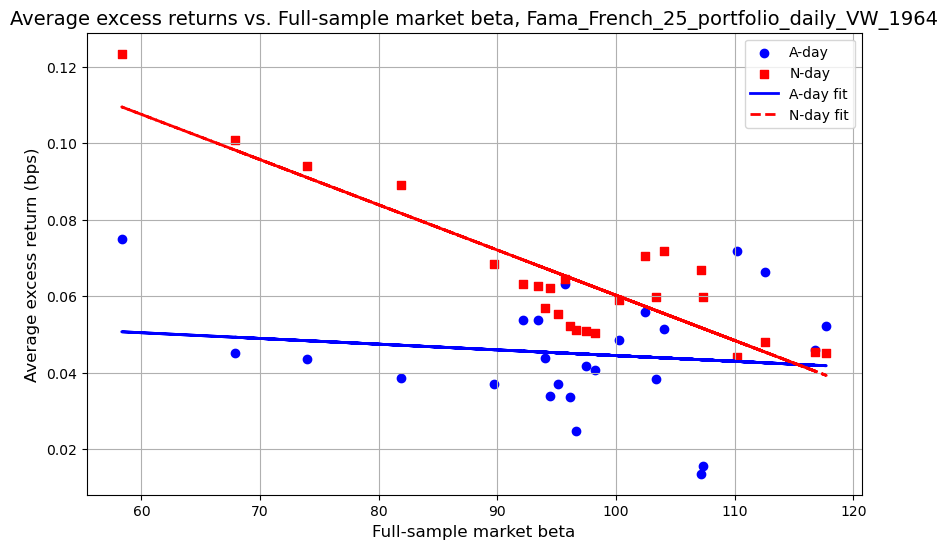

In [64]:
#Test on the 25 portfolios - Fama-French 25 portfolios daily VW from 1964

#Select date from 1964 only
Fama_French_25_portfolio_daily_VW_1964 = Fama_French_25_portfolio_daily_VW.loc[Fama_French_25_portfolio_daily_VW['Date'] >= pd.to_datetime('1964-01-01').date()]
Fama_French_25_portfolio_daily_VW_1964 = Fama_French_25_portfolio_daily_VW_1964.reset_index(drop=True)

Fama_French_25_portfolio_daily_VW_A_Day['Date'] = pd.to_datetime(Fama_French_25_portfolio_daily_VW_A_Day['Date'])
Fama_French_25_portfolio_daily_VW_1964_A_Day = Fama_French_25_portfolio_daily_VW_A_Day.loc[Fama_French_25_portfolio_daily_VW_A_Day['Date'] >= pd.to_datetime('1964-01-01')].reset_index(drop=True)

Fama_French_25_portfolio_daily_VW_N_Day['Date'] = pd.to_datetime(Fama_French_25_portfolio_daily_VW_N_Day['Date'])
Fama_French_25_portfolio_daily_VW_1964_N_Day = Fama_French_25_portfolio_daily_VW_N_Day.loc[Fama_French_25_portfolio_daily_VW_N_Day['Date'] >= pd.to_datetime('1964-01-01')].reset_index(drop=True)


#Compute rolling betas for the stock market daily returns
Fama_French_25_portfolio_daily_VW_1964_rolling_betas = rolling_betas(Fama_French_25_portfolio_daily_VW_1964)


#Compute Fama-MacBeth regression for the portfolios
gammas_A = fama_macbeth_cross_sectional(Fama_French_25_portfolio_daily_VW_1964_A_Day, Fama_French_25_portfolio_daily_VW_1964_rolling_betas)
gammas_N = fama_macbeth_cross_sectional(Fama_French_25_portfolio_daily_VW_1964_N_Day, Fama_French_25_portfolio_daily_VW_1964_rolling_betas)

#Summarize results
results = summarize_fama_macbeth_results(gammas_A, gammas_N)
print(results)

#Plot the results
plot_full_sample_beta_vs_excess_return(Fama_French_25_portfolio_daily_VW_1964, Fama_French_25_portfolio_daily_VW_1964_A_Day, Fama_French_25_portfolio_daily_VW_1964_N_Day)

In [21]:
#Test on the 25 portfolios, 10 Industry portfolio and Beta-sorted portfolio daily EW from 1990

#Ensure the 'Date' column is in datetime format for all datasets
stock_market_daily_returns['Date'] = pd.to_datetime(stock_market_daily_returns['Date'], errors='coerce')
Fama_French_25_portfolio_daily_EV['Date'] = pd.to_datetime(Fama_French_25_portfolio_daily_EV['Date'], errors='coerce')
Ten_industry_portfolio_daily_EV['Date'] = pd.to_datetime(Ten_industry_portfolio_daily_EV['Date'], errors='coerce')

#Select date from 1990 only
stock_market_daily_returns_1990 = stock_market_daily_returns.loc[stock_market_daily_returns['Date'] >= pd.to_datetime('1990-01-01')].reset_index(drop=True)
Fama_French_25_portfolio_daily_EV_1990 = Fama_French_25_portfolio_daily_EV.loc[Fama_French_25_portfolio_daily_EV['Date'] >= pd.to_datetime('1990-01-01')].reset_index(drop=True)
Ten_industry_portfolio_daily_EV_1990 = Ten_industry_portfolio_daily_EV.loc[Ten_industry_portfolio_daily_EV['Date'] >= pd.to_datetime('1990-01-01')].reset_index(drop=True)

# Convert numerical columns to float32 for memory efficiency
stock_market_daily_returns_1990 = stock_market_daily_returns_1990.astype({col: 'float32' for col in stock_market_daily_returns_1990.select_dtypes(include='number').columns})
Fama_French_25_portfolio_daily_EV_1990 = Fama_French_25_portfolio_daily_EV_1990.astype({col: 'float32' for col in Fama_French_25_portfolio_daily_EV_1990.select_dtypes(include='number').columns})
Ten_industry_portfolio_daily_EV_1990 = Ten_industry_portfolio_daily_EV_1990.astype({col: 'float32' for col in Ten_industry_portfolio_daily_EV_1990.select_dtypes(include='number').columns})

#Compute rolling betas for the stock market daily returns
stock_market_daily_returns_1990_rolling_betas = rolling_betas(stock_market_daily_returns_1990)

#Build beta-sorted portfolios from 1964 to 2011
Beta_sorted_portfolios_1990 = build_beta_decile_portfolios(stock_market_daily_returns_1990_rolling_betas,stock_market_daily_returns_1990)

#Merge data
portfolio_1990 = Beta_sorted_portfolios_1990.merge(
    Fama_French_25_portfolio_daily_EV_1990, on='Date', how='outer'
).merge(
    Ten_industry_portfolio_daily_EV_1990, on='Date', how='outer'
)
cols = ['Date'] + sorted([col for col in portfolio_1990.columns if col != 'Date'])
portfolio_1990 = portfolio_1990[cols]

#Split the portfolios into A and N days
portfolio_1990_A_Day = portfolio_1990[portfolio_1990['Date'].isin(all_A_dates)].reset_index(drop=True)
portfolio_1990_N_Day = portfolio_1990[~portfolio_1990['Date'].isin(all_A_dates)].reset_index(drop=True)

#Compute rolling betas for the stock market daily returns
portfolio_1990_rolling_betas = rolling_betas(portfolio_1990)

#Compute Fama-MacBeth regression for the portfolios
gammas_A = fama_macbeth_cross_sectional(portfolio_1990_A_Day, portfolio_1990_rolling_betas)
gammas_N = fama_macbeth_cross_sectional(portfolio_1990_N_Day, portfolio_1990_rolling_betas)

#Summarize results
results = summarize_fama_macbeth_results(gammas_A, gammas_N)
print(results)

#Plot the results
plot_full_sample_beta_vs_excess_return(portfolio_1990, portfolio_1990_A_Day, portfolio_1990_N_Day)

Rolling beta estimation: 100%|██████████| 420/420 [41:40<00:00,  5.95s/it] 
C:\Users\bazel\AppData\Local\Temp\ipykernel_11724\343476799.py:34: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  portfolio_1990_A_Day = portfolio_1990[portfolio_1990['Date'].isin(all_A_dates)].reset_index(drop=True)
C:\Users\bazel\AppData\Local\Temp\ipykernel_11724\343476799.py:35: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  portfolio_1990_N_Day = portfolio_1990[~portfolio_1990['Date'].isin(all_A_dates)].reset_index(drop=True)
Fama-MacBeth regression: 100%|██████████| 8051/8051 [00:17<00:00, 456.21it/

               Intercept  Intercept t-stat      Beta  Beta t-stat    Avg R²
a-day          -0.003304         -0.617960  0.000737     1.463682  0.380027
n-day           0.010144          6.463148  0.000362     2.753274  0.354544
a-day − n-day  -0.013448         -2.413564  0.000375     0.721272  0.025483


NameError: name 'portfolio_1964' is not defined

               Intercept  Intercept t-stat      Beta  Beta t-stat    Avg R²
a-day           0.007524          0.258605  0.000480     1.157025  0.224551
n-day           0.116173         14.486211 -0.000623    -5.527021  0.214925
a-day − n-day  -0.108649         -3.600261  0.001103     2.564381  0.009626


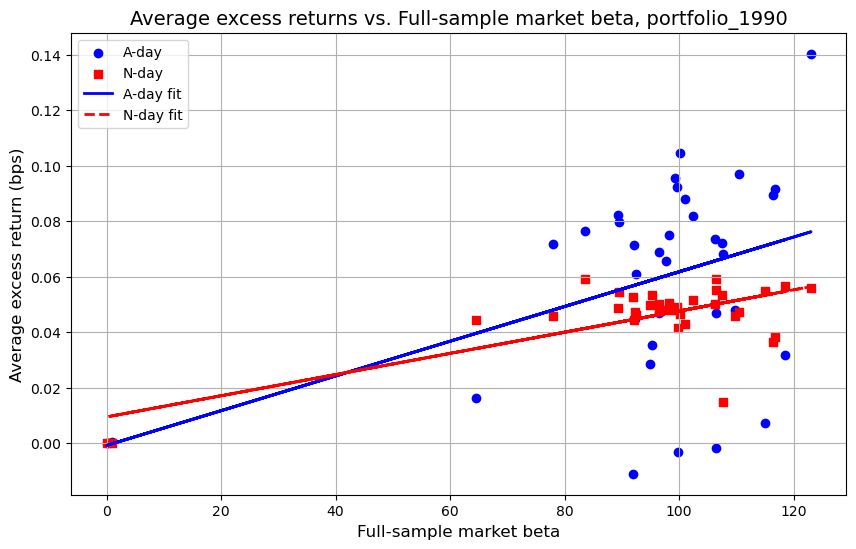

In [65]:
print(results)
plot_full_sample_beta_vs_excess_return(portfolio_1990, portfolio_1990_A_Day, portfolio_1990_N_Day)

In [75]:
#Test on the 25 portfolios, 10 Industry portfolio and Beta-sorted portfolio daily EW from 1980

#Ensure the 'Date' column is in datetime format for all datasets
stock_market_daily_returns['Date'] = pd.to_datetime(stock_market_daily_returns['Date'], errors='coerce')
Fama_French_25_portfolio_daily_EV['Date'] = pd.to_datetime(Fama_French_25_portfolio_daily_EV['Date'], errors='coerce')
Ten_industry_portfolio_daily_EV['Date'] = pd.to_datetime(Ten_industry_portfolio_daily_EV['Date'], errors='coerce')

#Select date from 1990 only
stock_market_daily_returns_1980 = stock_market_daily_returns.loc[stock_market_daily_returns['Date'] >= pd.to_datetime('1980-01-01')].reset_index(drop=True)
Fama_French_25_portfolio_daily_EV_1980 = Fama_French_25_portfolio_daily_EV.loc[Fama_French_25_portfolio_daily_EV['Date'] >= pd.to_datetime('1980-01-01')].reset_index(drop=True)
Ten_industry_portfolio_daily_EV_1980 = Ten_industry_portfolio_daily_EV.loc[Ten_industry_portfolio_daily_EV['Date'] >= pd.to_datetime('1980-01-01')].reset_index(drop=True)

# Convert numerical columns to float32 for memory efficiency
stock_market_daily_returns_1980 = stock_market_daily_returns_1980.astype({col: 'float32' for col in stock_market_daily_returns_1980.select_dtypes(include='number').columns})
Fama_French_25_portfolio_daily_EV_1980 = Fama_French_25_portfolio_daily_EV_1980.astype({col: 'float32' for col in Fama_French_25_portfolio_daily_EV_1980.select_dtypes(include='number').columns})
Ten_industry_portfolio_daily_EV_1980 = Ten_industry_portfolio_daily_EV_1980.astype({col: 'float32' for col in Ten_industry_portfolio_daily_EV_1980.select_dtypes(include='number').columns})

#Compute rolling betas for the stock market daily returns
stock_market_daily_returns_1980_rolling_betas = rolling_betas(stock_market_daily_returns_1980)

#Build beta-sorted portfolios from 1990to 2024
Beta_sorted_portfolios_1980 = build_beta_decile_portfolios(stock_market_daily_returns_1980_rolling_betas,stock_market_daily_returns_1980)

#Merge data
portfolio_1980 = Beta_sorted_portfolios_1980.merge(
    Fama_French_25_portfolio_daily_EV_1980, on='Date', how='outer'
).merge(
    Ten_industry_portfolio_daily_EV_1980, on='Date', how='outer'
)
cols = ['Date'] + sorted([col for col in portfolio_1980.columns if col != 'Date'])
portfolio_1980 = portfolio_1980[cols]

#Split the portfolios into A and N days
portfolio_1980_A_Day = portfolio_1980[portfolio_1980['Date'].isin(all_A_dates)].reset_index(drop=True)
portfolio_1980_N_Day = portfolio_1980[~portfolio_1980['Date'].isin(all_A_dates)].reset_index(drop=True)

#Compute rolling betas for the stock market daily returns
portfolio_1980_rolling_betas = rolling_betas(portfolio_1980)

#Compute Fama-MacBeth regression for the portfolios
gammas_A = fama_macbeth_cross_sectional(portfolio_1980_A_Day, portfolio_1980_rolling_betas)
gammas_N = fama_macbeth_cross_sectional(portfolio_1980_N_Day, portfolio_1980_rolling_betas)

#Summarize results
results = summarize_fama_macbeth_results(gammas_A, gammas_N)

Rolling beta estimation: 100%|██████████| 540/540 [50:31<00:00,  5.61s/it]
C:\Users\bazel\AppData\Local\Temp\ipykernel_11724\365793642.py:34: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  portfolio_1980_A_Day = portfolio_1980[portfolio_1980['Date'].isin(all_A_dates)].reset_index(drop=True)
C:\Users\bazel\AppData\Local\Temp\ipykernel_11724\365793642.py:35: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  portfolio_1980_N_Day = portfolio_1980[~portfolio_1980['Date'].isin(all_A_dates)].reset_index(drop=True)
Fama-MacBeth regression: 100%|██████████| 10336/10336 [00:22<00:00, 461.58it

               Intercept  Intercept t-stat      Beta  Beta t-stat    Avg R²
a-day          -0.010341         -1.742350  0.000763     1.637167  0.391896
n-day           0.011065          8.226331  0.000375     3.438634  0.357560
a-day − n-day  -0.021406         -3.517458  0.000388     0.810524  0.034336


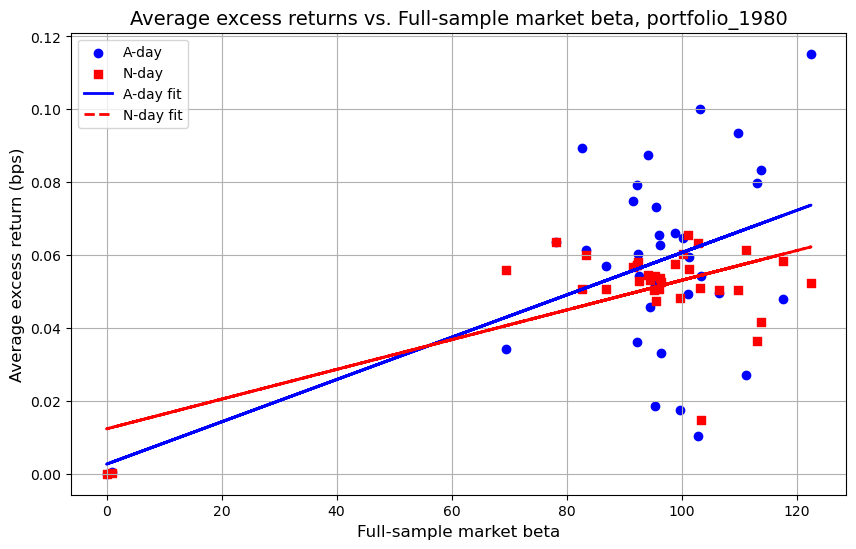

In [76]:
print(results)

#Plot the results
plot_full_sample_beta_vs_excess_return(portfolio_1980, portfolio_1980_A_Day, portfolio_1980_N_Day)

In [19]:
#Test on the 25 portfolios, 10 Industry portfolio and Beta-sorted portfolio daily EV from 1964

#Ensure the 'Date' column is in datetime format for all datasets
stock_market_daily_returns['Date'] = pd.to_datetime(stock_market_daily_returns['Date'], errors='coerce')
Fama_French_25_portfolio_daily_EV['Date'] = pd.to_datetime(Fama_French_25_portfolio_daily_EV['Date'], errors='coerce')
Ten_industry_portfolio_daily_EV['Date'] = pd.to_datetime(Ten_industry_portfolio_daily_EV['Date'], errors='coerce')

#Select date from 1964 only
stock_market_daily_returns_1964 = stock_market_daily_returns.loc[stock_market_daily_returns['Date'] >= pd.to_datetime('1964-01-01')].reset_index(drop=True)
Fama_French_25_portfolio_daily_EV_1964 = Fama_French_25_portfolio_daily_EV.loc[Fama_French_25_portfolio_daily_EV['Date'] >= pd.to_datetime('1964-01-01')].reset_index(drop=True)
Ten_industry_portfolio_daily_EV_1964 = Ten_industry_portfolio_daily_EV.loc[Ten_industry_portfolio_daily_EV['Date'] >= pd.to_datetime('1964-01-01')].reset_index(drop=True)

# Convert numerical columns to float32 for memory efficiency
stock_market_daily_returns_1964 = stock_market_daily_returns_1964.astype({col: 'float32' for col in stock_market_daily_returns_1964.select_dtypes(include='number').columns})
Fama_French_25_portfolio_daily_EV_1964 = Fama_French_25_portfolio_daily_EV_1964.astype({col: 'float32' for col in Fama_French_25_portfolio_daily_EV_1964.select_dtypes(include='number').columns})
Ten_industry_portfolio_daily_EV_1964 = Ten_industry_portfolio_daily_EV_1964.astype({col: 'float32' for col in Ten_industry_portfolio_daily_EV_1964.select_dtypes(include='number').columns})

#Compute rolling betas for the stock market daily returns
stock_market_daily_returns_1964_rolling_betas = rolling_betas(stock_market_daily_returns_1964)

#Build beta-sorted portfolios from 1990to 2024
Beta_sorted_portfolios_1964 = build_beta_decile_portfolios(stock_market_daily_returns_1964_rolling_betas,stock_market_daily_returns_1964)

#Merge data
portfolio_1964 = Beta_sorted_portfolios_1964.merge(
    Fama_French_25_portfolio_daily_EV_1964, on='Date', how='outer'
).merge(
    Ten_industry_portfolio_daily_EV_1964, on='Date', how='outer'
)
cols = ['Date'] + sorted([col for col in portfolio_1964.columns if col != 'Date'])
portfolio_1964 = portfolio_1964[cols]

#Split the portfolios into A and N days
portfolio_1964_A_Day = portfolio_1964[portfolio_1964['Date'].isin(all_A_dates)].reset_index(drop=True)
portfolio_1964_N_Day = portfolio_1964[~portfolio_1964['Date'].isin(all_A_dates)].reset_index(drop=True)

#Compute rolling betas for the stock market daily returns
portfolio_1964_rolling_betas = rolling_betas(portfolio_1964)

#Compute Fama-MacBeth regression for the portfolios
gammas_A = fama_macbeth_cross_sectional(portfolio_1964_A_Day, portfolio_1964_rolling_betas)
gammas_N = fama_macbeth_cross_sectional(portfolio_1964_N_Day, portfolio_1964_rolling_betas)

#Summarize results
results = summarize_fama_macbeth_results(gammas_A, gammas_N)

Rolling beta estimation: 100%|██████████| 732/732 [1:03:23<00:00,  5.20s/it]
C:\Users\bazel\AppData\Local\Temp\ipykernel_7124\3839505392.py:34: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  portfolio_1964_A_Day = portfolio_1964[portfolio_1964['Date'].isin(all_A_dates)].reset_index(drop=True)
C:\Users\bazel\AppData\Local\Temp\ipykernel_7124\3839505392.py:35: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  portfolio_1964_N_Day = portfolio_1964[~portfolio_1964['Date'].isin(all_A_dates)].reset_index(drop=True)
Fama-MacBeth regression: 100%|██████████| 14002/14002 [00:29<00:00, 467.03

               Intercept  Intercept t-stat      Beta  Beta t-stat    Avg R²
a-day          -0.007787         -1.793242  0.000588     1.639330  0.385207
n-day           0.008464          8.778476  0.000394     4.520075  0.359467
a-day − n-day  -0.016251         -3.653441  0.000195     0.526935  0.025741


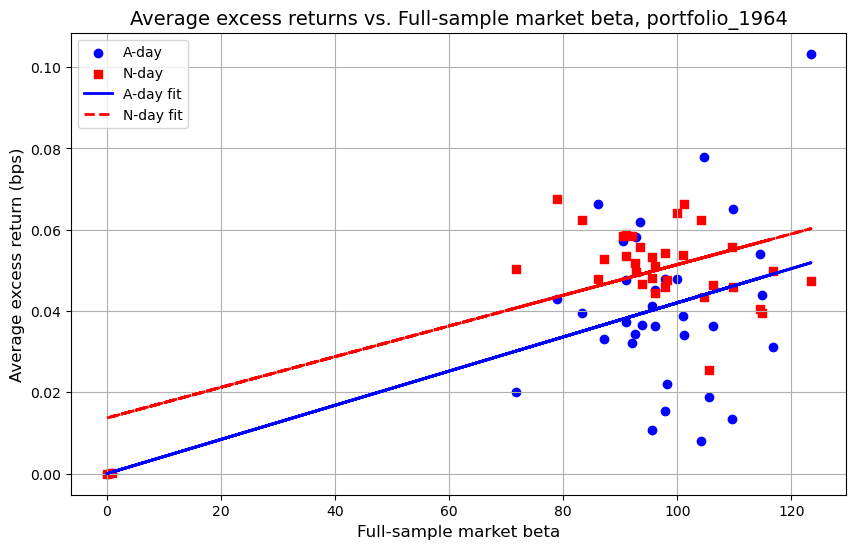

In [20]:
print(results)

#Plot the results
plot_full_sample_beta_vs_excess_return(portfolio_1964, portfolio_1964_A_Day, portfolio_1964_N_Day)

Fama-MacBeth regression: 100%|██████████| 13779/13779 [00:28<00:00, 487.56it/s]


               Intercept  Intercept t-stat      Beta  Beta t-stat    Avg R²
a-day           0.000010          0.053253  0.000479     1.216367  0.587314
n-day           0.000778         18.519950 -0.000253    -2.417907  0.575023
a-day − n-day  -0.000769         -4.194437  0.000733     1.797016  0.012292


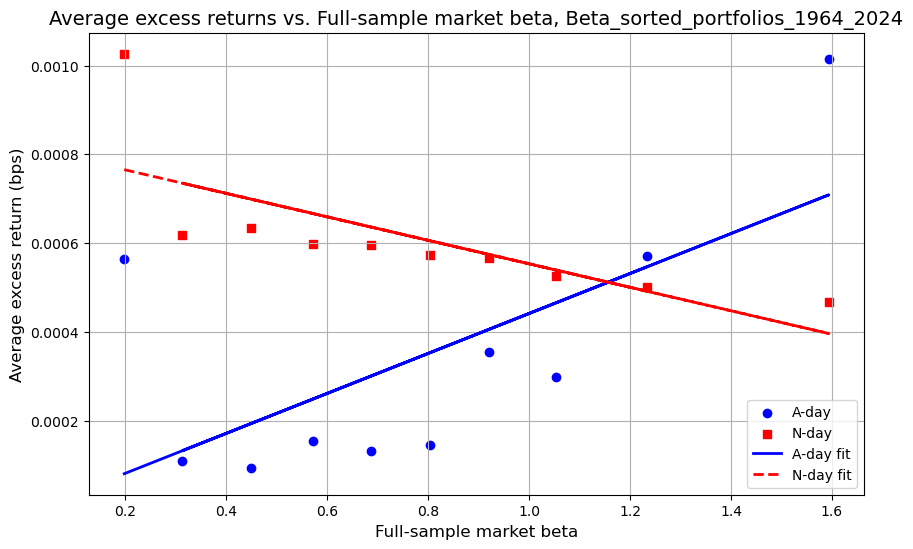

In [22]:
#Test beta-sorted portfolio from 1964 to 2024

#Select stock market returns only from 1964 to 2024
stock_market_daily_returns['Date'] = pd.to_datetime(stock_market_daily_returns['Date'])
stock_market_daily_returns_1964_2024 = stock_market_daily_returns.loc[
    (stock_market_daily_returns['Date'] >= pd.to_datetime('1964-01-01')) 
    ].reset_index(drop=True)

#Compute rolling betas for the stock market daily returns
stock_market_daily_returns_1964_2024_rolling_betas = rolling_betas(stock_market_daily_returns_1964_2024)

#Build beta-sorted portfolios from 1964 to 2011
Beta_sorted_portfolios_1964_2024 = build_beta_decile_portfolios(
    stock_market_daily_returns_1964_2024_rolling_betas,stock_market_daily_returns_1964_2024
    )

#Compute rolling betas for the portfolios
Beta_sorted_portfolioss_1964_2024_rolling_betas = rolling_betas(Beta_sorted_portfolios_1964_2024)

#Split the portfolios into A and N days
Beta_sorted_portfolios_1964_2024_A_Day = Beta_sorted_portfolios_1964_2024[
    Beta_sorted_portfolios_1964_2024.index.isin(stock_market_daily_returns_A_Day['Date'])
    ]
Beta_sorted_portfolios_1964_2024_N_Day = Beta_sorted_portfolios_1964_2024[
    Beta_sorted_portfolios_1964_2024.index.isin(stock_market_daily_returns_N_Day['Date'])
    ]

#Compute Fama-MacBeth regression for the portfolios
gammas_A = fama_macbeth_cross_sectional(Beta_sorted_portfolios_1964_2024_A_Day, Beta_sorted_portfolioss_1964_2024_rolling_betas)
gammas_N = fama_macbeth_cross_sectional(Beta_sorted_portfolios_1964_2024_N_Day, Beta_sorted_portfolioss_1964_2024_rolling_betas)

#Summarize results
results_Beta_sorted_portfolios = summarize_fama_macbeth_results(gammas_A, gammas_N)
print(results_Beta_sorted_portfolios)

#Plot the results
plot_full_sample_beta_vs_excess_return(
    Beta_sorted_portfolios_1964_2024, 
    Beta_sorted_portfolios_1964_2024_A_Day, 
    Beta_sorted_portfolios_1964_2024_N_Day
    )

Fama-MacBeth regression: 100%|██████████| 10778/10778 [00:22<00:00, 482.72it/s]


               Intercept  Intercept t-stat      Beta  Beta t-stat    Avg R²
a-day           0.000098          0.543912  0.000752     1.766218  0.569238
n-day           0.000810         19.647317 -0.000298    -2.616461  0.564470
a-day − n-day  -0.000713         -3.873276  0.001050     2.382408  0.004768


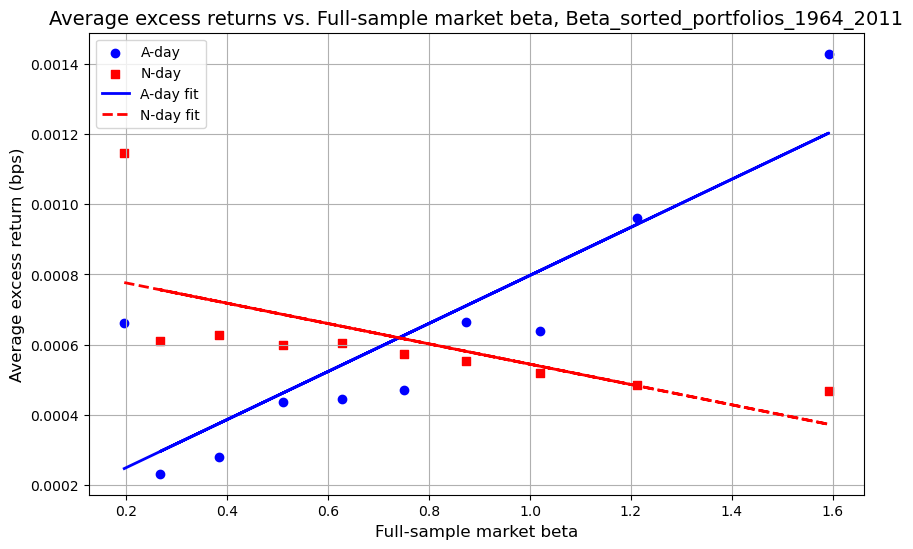

In [23]:
#Test beta-sorted portfolio from 1964 to 2011

#Select stock market returns only from 1964 to 2011
stock_market_daily_returns['Date'] = pd.to_datetime(stock_market_daily_returns['Date'])
stock_market_daily_returns_1964_2011 = stock_market_daily_returns.loc[
    (stock_market_daily_returns['Date'] >= pd.to_datetime('1964-01-01')) & (stock_market_daily_returns['Date'] <= pd.to_datetime('2011-12-31')) 
    ].reset_index(drop=True)

#Compute rolling betas for the stock market daily returns
stock_market_daily_returns_1964_2011_rolling_betas = rolling_betas(stock_market_daily_returns_1964_2011)

#Build beta-sorted portfolios from 1964 to 2011
Beta_sorted_portfolios_1964_2011 = build_beta_decile_portfolios(stock_market_daily_returns_1964_2011_rolling_betas,stock_market_daily_returns_1964_2011)

#Compute rolling betas for the portfolios
Beta_sorted_portfolioss_1964_2011_rolling_betas = rolling_betas(Beta_sorted_portfolios_1964_2011)

#Split the portfolios into A and N days
Beta_sorted_portfolios_1964_2011_A_Day = Beta_sorted_portfolios_1964_2011[
    Beta_sorted_portfolios_1964_2011.index.isin(stock_market_daily_returns_A_Day['Date'])
    ]
Beta_sorted_portfolios_1964_2011_N_Day = Beta_sorted_portfolios_1964_2011[
    Beta_sorted_portfolios_1964_2011.index.isin(stock_market_daily_returns_N_Day['Date'])
    ]

#Compute Fama-MacBeth regression for the portfolios
gammas_A = fama_macbeth_cross_sectional(Beta_sorted_portfolios_1964_2011_A_Day, Beta_sorted_portfolioss_1964_2011_rolling_betas)
gammas_N = fama_macbeth_cross_sectional(Beta_sorted_portfolios_1964_2011_N_Day, Beta_sorted_portfolioss_1964_2011_rolling_betas)

#Summarize results
results_Beta_sorted_portfolios = summarize_fama_macbeth_results(gammas_A, gammas_N)
print(results_Beta_sorted_portfolios)

#Plot the results
plot_full_sample_beta_vs_excess_return(Beta_sorted_portfolios_1964_2011, Beta_sorted_portfolios_1964_2011_A_Day, Beta_sorted_portfolios_1964_2011_N_Day)

Fama-MacBeth regression: 100%|██████████| 3211/3211 [00:06<00:00, 479.39it/s]


               Intercept  Intercept t-stat      Beta  Beta t-stat    Avg R²
a-day          -0.000341         -0.647461 -0.000684    -0.690583  0.654880
n-day           0.000644          5.203584 -0.000103    -0.403899  0.611264
a-day − n-day  -0.000985         -1.820043 -0.000581    -0.568104  0.043615


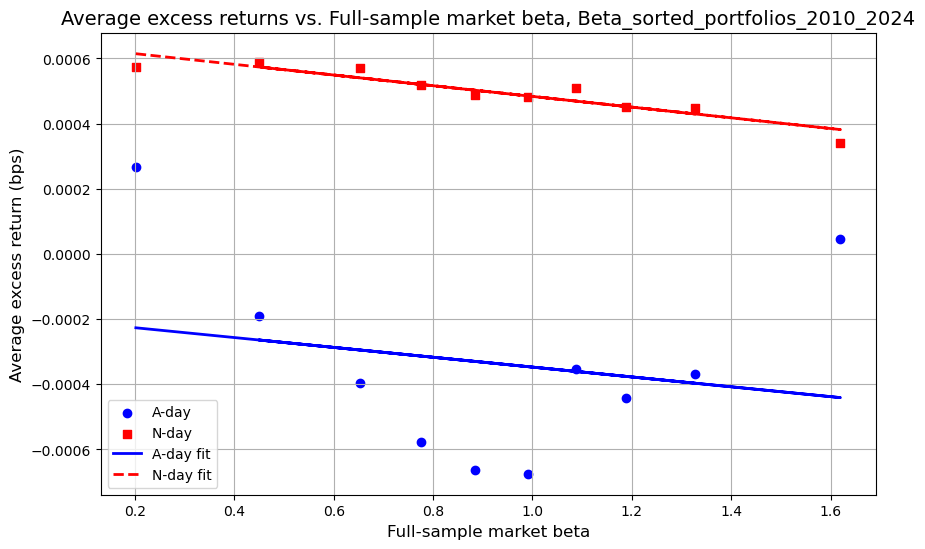

In [72]:
#Test beta-sorted portfolio from 2010 to 2024

#Select stock market returns only from 2010 to 2024
stock_market_daily_returns['Date'] = pd.to_datetime(stock_market_daily_returns['Date'])
stock_market_daily_returns_2010_2024 = stock_market_daily_returns.loc[
    (stock_market_daily_returns['Date'] >= pd.to_datetime('2010-01-01')) & (stock_market_daily_returns['Date'] <= pd.to_datetime('2024-12-31')) 
    ].reset_index(drop=True)

#Compute rolling betas for the stock market daily returns
stock_market_daily_returns_2010_2024_rolling_betas = rolling_betas(stock_market_daily_returns_2010_2024)

#Build beta-sorted portfolios from 1964 to 2011
Beta_sorted_portfolios_2010_2024 = build_beta_decile_portfolios(stock_market_daily_returns_2010_2024_rolling_betas,stock_market_daily_returns_2010_2024)

#Compute rolling betas for the portfolios
Beta_sorted_portfolioss_2010_2024_rolling_betas = rolling_betas(Beta_sorted_portfolios_2010_2024)

#Split the portfolios into A and N days
Beta_sorted_portfolios_2010_2024_A_Day = Beta_sorted_portfolios_2010_2024[
    Beta_sorted_portfolios_2010_2024.index.isin(stock_market_daily_returns_A_Day['Date'])
    ]
Beta_sorted_portfolios_2010_2024_N_Day = Beta_sorted_portfolios_2010_2024[
    Beta_sorted_portfolios_2010_2024.index.isin(stock_market_daily_returns_N_Day['Date'])
    ]

#Compute Fama-MacBeth regression for the portfolios
gammas_A = fama_macbeth_cross_sectional(Beta_sorted_portfolios_2010_2024_A_Day, Beta_sorted_portfolioss_2010_2024_rolling_betas)
gammas_N = fama_macbeth_cross_sectional(Beta_sorted_portfolios_2010_2024_N_Day, Beta_sorted_portfolioss_2010_2024_rolling_betas)

#Summarize results
results_Beta_sorted_portfolios = summarize_fama_macbeth_results(gammas_A, gammas_N)
print(results_Beta_sorted_portfolios)

#Plot the results
plot_full_sample_beta_vs_excess_return(Beta_sorted_portfolios_2010_2024, Beta_sorted_portfolios_2010_2024_A_Day, Beta_sorted_portfolios_2010_2024_N_Day)

Fama-MacBeth regression: 100%|██████████| 4361/4361 [00:09<00:00, 468.78it/s]


               Intercept  Intercept t-stat      Beta  Beta t-stat    Avg R²
a-day           0.000431          1.726263  0.001560     2.090368  0.575834
n-day           0.001153         15.519312 -0.000514    -2.299638  0.575520
a-day − n-day  -0.000722         -2.769851  0.002074     2.662544  0.000313


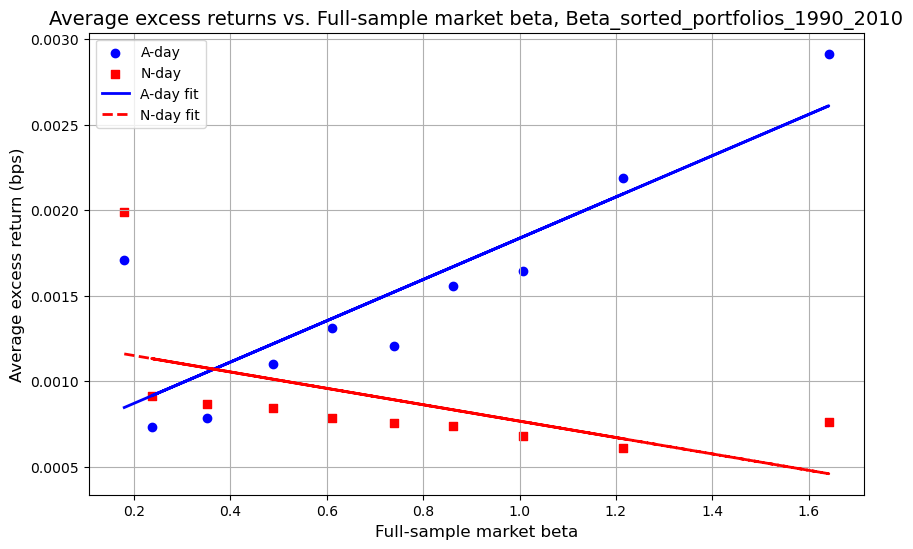

In [73]:
#Test beta-sorted portfolio from 1990 to 2010

#Select stock market returns only from 1990 to 2010
stock_market_daily_returns['Date'] = pd.to_datetime(stock_market_daily_returns['Date'])
stock_market_daily_returns_1990_2010 = stock_market_daily_returns.loc[
    (stock_market_daily_returns['Date'] >= pd.to_datetime('1990-01-01')) & (stock_market_daily_returns['Date'] <= pd.to_datetime('2010-01-01')) 
    ].reset_index(drop=True)

#Compute rolling betas for the stock market daily returns
stock_market_daily_returns_1990_2010_rolling_betas = rolling_betas(stock_market_daily_returns_1990_2010)

#Build beta-sorted portfolios from 1990 to 2010
Beta_sorted_portfolios_1990_2010 = build_beta_decile_portfolios(stock_market_daily_returns_1990_2010_rolling_betas,stock_market_daily_returns_1990_2010)

#Compute rolling betas for the portfolios
Beta_sorted_portfolioss_2010_2024_rolling_betas = rolling_betas(Beta_sorted_portfolios_1990_2010)

#Split the portfolios into A and N days
Beta_sorted_portfolios_1990_2010_A_Day = Beta_sorted_portfolios_1990_2010[
    Beta_sorted_portfolios_1990_2010.index.isin(stock_market_daily_returns_A_Day['Date'])
    ]
Beta_sorted_portfolios_1990_2010_N_Day = Beta_sorted_portfolios_1990_2010[
    Beta_sorted_portfolios_1990_2010.index.isin(stock_market_daily_returns_N_Day['Date'])
    ]

#Compute Fama-MacBeth regression for the portfolios
gammas_A = fama_macbeth_cross_sectional(Beta_sorted_portfolios_1990_2010_A_Day, Beta_sorted_portfolioss_2010_2024_rolling_betas)
gammas_N = fama_macbeth_cross_sectional(Beta_sorted_portfolios_1990_2010_N_Day, Beta_sorted_portfolioss_2010_2024_rolling_betas)

#Summarize results
results_Beta_sorted_portfolios = summarize_fama_macbeth_results(gammas_A, gammas_N)
print(results_Beta_sorted_portfolios)

#Plot the results
plot_full_sample_beta_vs_excess_return(Beta_sorted_portfolios_1990_2010, Beta_sorted_portfolios_1990_2010_A_Day, Beta_sorted_portfolios_1990_2010_N_Day)

Fama-MacBeth regression: 100%|██████████| 5727/5727 [00:12<00:00, 462.00it/s]


               Intercept  Intercept t-stat      Beta  Beta t-stat    Avg R²
a-day          -0.000254         -0.892989  0.000012     0.021686  0.561664
n-day           0.000593         11.670310 -0.000181    -1.504347  0.551684
a-day − n-day  -0.000847         -2.932161  0.000194     0.335526  0.009980


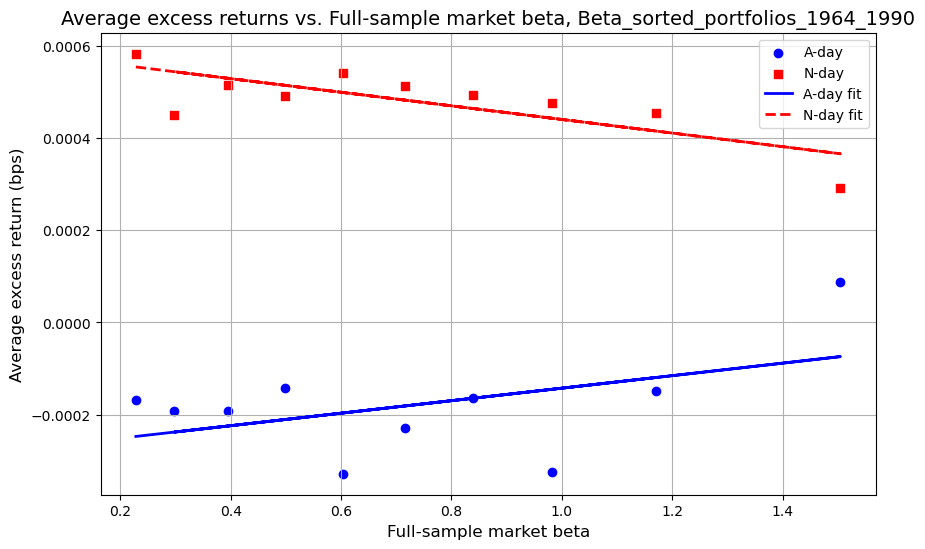

In [74]:
#Test beta-sorted portfolio from 1964 to 1990

#Select stock market returns only from 1964 to 1990
stock_market_daily_returns['Date'] = pd.to_datetime(stock_market_daily_returns['Date'])
stock_market_daily_returns_1964_1990 = stock_market_daily_returns.loc[
    (stock_market_daily_returns['Date'] >= pd.to_datetime('1964-01-01')) & (stock_market_daily_returns['Date'] <= pd.to_datetime('1990-01-01')) 
    ].reset_index(drop=True)

#Compute rolling betas for the stock market daily returns
stock_market_daily_returns_1964_1990_rolling_betas = rolling_betas(stock_market_daily_returns_1964_1990)

#Build beta-sorted portfolios from 1964 to 2011
Beta_sorted_portfolios_1964_1990 = build_beta_decile_portfolios(stock_market_daily_returns_1964_1990_rolling_betas,stock_market_daily_returns_1964_1990)

#Compute rolling betas for the portfolios
Beta_sorted_portfolioss_1964_1990_rolling_betas = rolling_betas(Beta_sorted_portfolios_1964_1990)

#Split the portfolios into A and N days
Beta_sorted_portfolios_1964_1990_A_Day = Beta_sorted_portfolios_1964_1990[
    Beta_sorted_portfolios_1964_1990.index.isin(stock_market_daily_returns_A_Day['Date'])
    ]
Beta_sorted_portfolios_1964_1990_N_Day = Beta_sorted_portfolios_1964_1990[
    Beta_sorted_portfolios_1964_1990.index.isin(stock_market_daily_returns_N_Day['Date'])
    ]

#Compute Fama-MacBeth regression for the portfolios
gammas_A = fama_macbeth_cross_sectional(Beta_sorted_portfolios_1964_1990_A_Day, Beta_sorted_portfolioss_1964_1990_rolling_betas)
gammas_N = fama_macbeth_cross_sectional(Beta_sorted_portfolios_1964_1990_N_Day, Beta_sorted_portfolioss_1964_1990_rolling_betas)

#Summarize results
results_Beta_sorted_portfolios = summarize_fama_macbeth_results(gammas_A, gammas_N)
print(results_Beta_sorted_portfolios)

#Plot the results
plot_full_sample_beta_vs_excess_return(Beta_sorted_portfolios_1964_1990, Beta_sorted_portfolios_1964_1990_A_Day, Beta_sorted_portfolios_1964_1990_N_Day)

Fama-MacBeth regression: 100%|██████████| 6883/6883 [00:13<00:00, 506.71it/s]


               Intercept  Intercept t-stat      Beta  Beta t-stat    Avg R²
a-day           0.000179          0.726317  0.001159     1.911977  0.562499
n-day           0.000956         18.322100 -0.000364    -2.332867  0.553285
a-day − n-day  -0.000777         -3.083830  0.001524     2.433130  0.009214


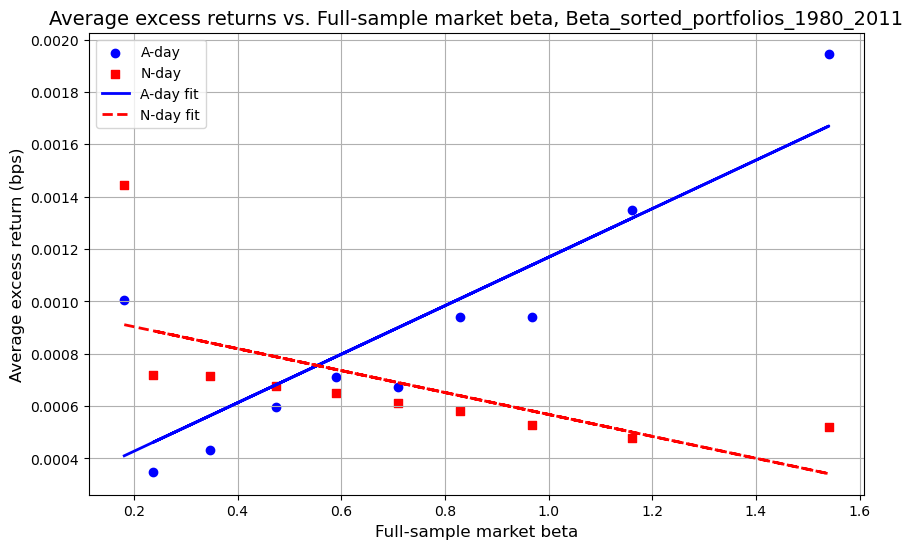

In [21]:
#Test beta-sorted portfolio from 1980 to 2011

#Select stock market returns only from 1980 to 2011
stock_market_daily_returns['Date'] = pd.to_datetime(stock_market_daily_returns['Date'])
stock_market_daily_returns_1980_2011 = stock_market_daily_returns.loc[
    (stock_market_daily_returns['Date'] >= pd.to_datetime('1980-01-01')) & (stock_market_daily_returns['Date'] <= pd.to_datetime('2011-01-01')) 
    ].reset_index(drop=True)

#Compute rolling betas for the stock market daily returns
stock_market_daily_returns_1980_2011_rolling_betas = rolling_betas(stock_market_daily_returns_1980_2011)

#Build beta-sorted portfolios from 1980 to 2011
Beta_sorted_portfolios_1980_2011 = build_beta_decile_portfolios(stock_market_daily_returns_1980_2011_rolling_betas,stock_market_daily_returns_1980_2011)

#Compute rolling betas for the portfolios
Beta_sorted_portfolioss_1980_2011_rolling_betas = rolling_betas(Beta_sorted_portfolios_1980_2011)

#Split the portfolios into A and N days
Beta_sorted_portfolios_1980_2011_A_Day = Beta_sorted_portfolios_1980_2011[
    Beta_sorted_portfolios_1980_2011.index.isin(stock_market_daily_returns_A_Day['Date'])
    ]
Beta_sorted_portfolios_1980_2011_N_Day = Beta_sorted_portfolios_1980_2011[
    Beta_sorted_portfolios_1980_2011.index.isin(stock_market_daily_returns_N_Day['Date'])
    ]

#Compute Fama-MacBeth regression for the portfolios
gammas_A = fama_macbeth_cross_sectional(Beta_sorted_portfolios_1980_2011_A_Day, Beta_sorted_portfolioss_1980_2011_rolling_betas)
gammas_N = fama_macbeth_cross_sectional(Beta_sorted_portfolios_1980_2011_N_Day, Beta_sorted_portfolioss_1980_2011_rolling_betas)

#Summarize results
results_Beta_sorted_portfolios = summarize_fama_macbeth_results(gammas_A, gammas_N)
print(results_Beta_sorted_portfolios)

#Plot the results
plot_full_sample_beta_vs_excess_return(Beta_sorted_portfolios_1980_2011, Beta_sorted_portfolios_1980_2011_A_Day, Beta_sorted_portfolios_1980_2011_N_Day)

JUNK CODE

In [71]:
# [#Step 2b - draw graph of the output as in the paper

# def plot_full_sample_beta_vs_excess_return(data, a_day_dates, n_day_dates):
#     """
#     Plot average excess returns against full-sample market betas for A-days and N-days.

#     Parameters:
#     - data: DataFrame where:
#         - rows are dates,
#         - columns: [portfolio1, ..., portfolioN, 'Equity Risk Premium', 'Risk-Free Rate'].
#     - a_day_dates: List or Series of A-day dates.
#     - n_day_dates: List or Series of N-day dates.
#     """
#     # Compute full-sample betas
#     full_sample_betas = compute_full_sample_betas(data)

#     # Split data into A-days and N-days
#     a_day_data = data[data.index.isin(a_day_dates)]
#     n_day_data = data[data.index.isin(n_day_dates)]

#     # Compute average excess returns for each portfolio
#     avg_excess_returns_a_day = a_day_data.iloc[:, :-2].sub(a_day_data['Risk-Free Rate'], axis=0).mean()
#     avg_excess_returns_n_day = n_day_data.iloc[:, :-2].sub(n_day_data['Risk-Free Rate'], axis=0).mean()

#     # Plot the results
#     plt.figure(figsize=(10, 6))
#     plt.scatter(full_sample_betas, avg_excess_returns_a_day, label='A-day', color='black', marker='o')
#     plt.scatter(full_sample_betas, avg_excess_returns_n_day, label='N-day', color='black', marker='s')

#     # Fit and plot regression lines
#     a_day_fit = np.polyfit(full_sample_betas, avg_excess_returns_a_day, 1)
#     n_day_fit = np.polyfit(full_sample_betas, avg_excess_returns_n_day, 1)
#     plt.plot(full_sample_betas, np.polyval(a_day_fit, full_sample_betas), color='black', linestyle='-', label='A-day fit')
#     plt.plot(full_sample_betas, np.polyval(n_day_fit, full_sample_betas), color='black', linestyle='--', label='N-day fit')

#     # Add labels and legend
#     plt.xlabel('Full-sample market beta', fontsize=12)
#     plt.ylabel('Average excess return (bps)', fontsize=12)
#     plt.title('Average excess returns vs. Full-sample market beta', fontsize=14)
#     plt.legend()
#     plt.grid(True)
#     plt.show()]

In [18]:
#Function that run the cross-section regression and the plot for a specific date range

def run_analysis_with_date_range(data, data_A_Day, data_N_Day, start_date, end_date):
    """
    Run analysis for a specific date range and produce the summarized table and graph.

    Parameters:
    - data: DataFrame containing the full dataset with 'Date', portfolios, 'Equity Risk Premium', and 'Risk-Free Rate'.
    - data_A_Day: DataFrame containing A-day data with 'Date' column.
    - data_N_Day: DataFrame containing N-day data with 'Date' column.
    - start_date: str, the beginning date in 'YYYY-MM-DD' format (e.g., '1964-01-01').
    - end_date: str, the end date in 'YYYY-MM-DD' format (e.g., '2011-12-31').

    Returns:
    - results: DataFrame summarizing the Fama-MacBeth regression results.
    - A graph showing average excess returns vs. full-sample market beta.
    """
    # Filter the main dataset for the specified date range
    filtered_data = data.loc[
        (data['Date'] >= pd.to_datetime(start_date).date()) &
        (data['Date'] <= pd.to_datetime(end_date).date())
    ].reset_index(drop=True)

    # Filter A-day and N-day datasets for the specified date range
    data_A_Day['Date'] = pd.to_datetime(data_A_Day['Date'])
    filtered_data_A_Day = data_A_Day.loc[
        (data_A_Day['Date'] >= pd.to_datetime(start_date)) &
        (data_A_Day['Date'] <= pd.to_datetime(end_date))
    ].reset_index(drop=True)

    data_N_Day['Date'] = pd.to_datetime(data_N_Day['Date'])
    filtered_data_N_Day = data_N_Day.loc[
        (data_N_Day['Date'] >= pd.to_datetime(start_date)) &
        (data_N_Day['Date'] <= pd.to_datetime(end_date))
    ].reset_index(drop=True)

    # Compute rolling betas for the filtered dataset
    rolling_betas_filtered = rolling_betas(filtered_data)

    # Compute Fama-MacBeth regression for A-days and N-days
    gammas_A = fama_macbeth_cross_sectional(filtered_data_A_Day, rolling_betas_filtered)
    gammas_N = fama_macbeth_cross_sectional(filtered_data_N_Day, rolling_betas_filtered)

    # Summarize results
    results = summarize_fama_macbeth_results(gammas_A, gammas_N)
    print(results)

    # Plot the results
    plot_full_sample_beta_vs_excess_return(filtered_data, filtered_data_A_Day, filtered_data_N_Day)

    return results

In [ ]:
#Step 2c - Pooled regression with an interaction term between an a-day dummy (Ann) and the market beta (Ann. beta)

import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col

def run_pooled_panel_regression_from_split_adapted(returns_A_day, returns_N_day, rolling_betas_df):
    """
    Run pooled panel regression using precomputed A-day and N-day returns, and rolling betas.

    Parameters:
    - returns_A_day: DataFrame with wide format (Date index or column, tickers as columns)
    - returns_N_day: Same as above for non-announcement days
    - rolling_betas_df: DataFrame from `rolling_betas` (index = Date, columns = tickers, values = Beta)

    Returns:
    - model: statsmodels regression results object
    - summary_table: summary_col-formatted table
    """

    # STEP 1: Convert betas to long format
    betas_long = rolling_betas_df.stack().reset_index()
    betas_long.columns = ['Date', 'Ticker', 'Beta']
    betas_long['Date'] = pd.to_datetime(betas_long['Date'])

    # STEP 2: Label A and N days
    returns_A_day = returns_A_day.copy()
    returns_N_day = returns_N_day.copy()
    returns_A_day['A_day_dummy'] = 1
    returns_N_day['A_day_dummy'] = 0

    # STEP 3: Concatenate and ensure 'Date' column exists
    full_returns = pd.concat([returns_A_day, returns_N_day], ignore_index=True)

    if 'Date' not in full_returns.columns:
        full_returns = full_returns.copy()
        full_returns.index.name = 'Date'
        full_returns = full_returns.reset_index()

    full_returns['Date'] = pd.to_datetime(full_returns['Date'])

    # STEP 4: Melt to long format (assumes tickers are columns)
    value_vars = [col for col in full_returns.columns if col not in ['Date', 'Equity Risk Premium', 'Risk-Free Rate', 'A_day_dummy']]
    full_returns = full_returns.melt(
        id_vars=['Date', 'Equity Risk Premium', 'Risk-Free Rate', 'A_day_dummy'],
        value_vars=value_vars,
        var_name='Ticker',
        value_name='Return'
    )

    # STEP 5: Merge with rolling betas
    merged = pd.merge(full_returns, betas_long, on=['Date', 'Ticker'], how='inner')

    # STEP 6: Regression variables
    merged['Excess_Return'] = merged['Return'] - merged['Risk-Free Rate']
    merged['Beta_x_A'] = merged['Beta'] * merged['A_day_dummy']

    # STEP 7: Regression with clustered SEs by date
    X = sm.add_constant(merged[['Beta', 'A_day_dummy', 'Beta_x_A']])
    y = merged['Excess_Return']
    model = sm.OLS(y, X).fit(cov_type='cluster', cov_kwds={'groups': merged['Date']})

    # STEP 8: Table
    summary_table = summary_col(
        [model],
        stars=True,
        model_names=['Pooled Regression'],
        info_dict={
            'R²': lambda x: f"{x.rsquared:.3f}",
            'N': lambda x: f"{int(x.nobs)}"
        }
    )

    return model, summary_table

In [ ]:
#test on data from 1964 to 2011
model, table = run_pooled_panel_regression_from_split_adapted(
    Beta_sorted_portfolios_A_Day,
    Beta_sorted_portfolios_N_Day,
    Beta_sorted_portfolios_rolling_betas
)
print(table)